In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [126]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [127]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

labels = (["Cotton"]*14 + ["Acrylic"]*18 + ["Nylon"]*18 + ["PP/PE"]*8 + ["Polyester"]*17 + ["Silk"]*11 + ["Wool"]*23)

ranges = [(24, 38), (50, 68), (70, 88), (88, 96), (96, 113), (125, 136), (137, 160)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums_labeled = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums_labeled.insert(loc = 2, column = "Labels", value = labels)
spectrums_labeled.iloc[:, :5].head(20)


,Spectrum_ID,Subtype,Labels,4000.0,3999.0
0,25,Cotton,Cotton,99.10,99.11
1,26,Cotton,Cotton,99.26,99.28
2,27,Cotton,Cotton,99.89,99.89
3,28,Cotton,Cotton,99.59,99.60
4,29,Cotton,Cotton,100.71,100.72
5,30,Cotton,Cotton,99.95,99.96
6,31,Cotton,Cotton,101.33,101.33
7,32,Cotton,Cotton,100.02,100.02
8,33,Cotton,Cotton,100.45,100.47
9,34,Cotton,Cotton,100.07,100.07


In [128]:
spectrums = spectrums_labeled.drop(columns=["Subtype"])

L = spectrums.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 2:] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 2:].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df = pd.concat([meta, smoothed], axis=1)

final_df.iloc[:20, :6].head(20)

,Spectrum_ID,Labels,4000.0,3999.0,3998.0,3997.0
0,25,Cotton,-0.622644,-0.612657,-0.610001,-0.613199
1,26,Cotton,-0.615384,-0.601185,-0.590786,-0.584005
2,27,Cotton,-0.581537,-0.581484,-0.581587,-0.581481
3,28,Cotton,-0.639473,-0.626938,-0.620960,-0.619838
4,29,Cotton,-0.629731,-0.620984,-0.612284,-0.604668
5,30,Cotton,-0.632839,-0.624660,-0.625329,-0.632624
6,31,Cotton,-0.659039,-0.656144,-0.651993,-0.647204
7,32,Cotton,-0.565450,-0.563970,-0.562109,-0.560645
8,33,Cotton,-0.622046,-0.595300,-0.582625,-0.580772
9,34,Cotton,-0.576293,-0.576736,-0.580609,-0.586606


In [141]:
pca_full = PCA()
pca_full.fit(final_df.iloc[:, 2:].values)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95%, 99% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(n_components_95)
print(n_components_99)

12
27


(109, 12)


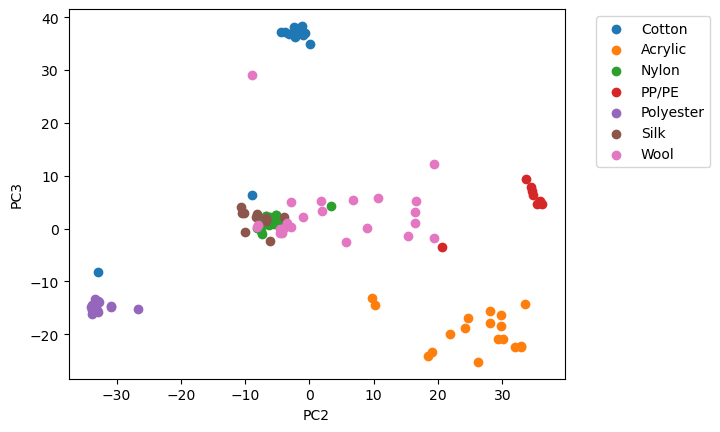

In [142]:
labels = final_df["Labels"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=12)
pca_data = pca.fit_transform(final_df.iloc[:, 2:].values)
print(pca_data.shape)

for lab in uniques:
    idx = labels == lab
    plt.scatter(pca_data[idx, 1], pca_data[idx, 2], label=lab)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(pca_data, labels, test_size=0.2, stratify=labels, random_state=57)

svm = SVC(kernel = "rbf", C=1, gamma="scale")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))